In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio


In [2]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [3]:
df_jan = pd.read_excel('Data/JAN 2025.xlsx')
df_feb = pd.read_excel('Data/FEB 2025.xlsx')
df_mar = pd.read_excel('Data/MARCH 2025.xlsx')
df_apr = pd.read_excel('Data/APRIL 2025.xlsx')
df_may = pd.read_excel('Data/MAY 2025.xlsx')
df_jun = pd.read_excel('Data/JUNE 2025.xlsx')
df_jul = pd.read_excel('Data/JULY 2025.xlsx')
df_aug = pd.read_excel('Data/AUGUST 2025.xlsx')



In [4]:
df_jan.head()

,ZUPRICIN OINTMENT,2025-01-02 00:00:00,1,1.1,0,0.1,800,Decrement
0,ZUPRICIN OINTMENT,2025-01-06,0.0,1000.0,1000,0.0,0.0,Adjust Increment
1,ZUPRICIN OINTMENT,2025-01-06,1000.0,1.0,999,0.0,800.0,Decrement
2,ZUPRICIN OINTMENT,2025-01-09,999.0,1.0,998,0.0,800.0,Decrement
3,ZUPRICIN OINTMENT,2025-01-10,998.0,1.0,997,0.0,800.0,Decrement
4,ZUPRICIN OINTMENT,2025-01-11,997.0,1.0,996,0.0,800.0,Decrement


In [5]:
# Standardize January headers to match other months
jan_columns = [
    "Item name",
    "Transaction Date",
    "Opening Stock",
    "QTY transacted",
    "Closing Stock",
    "Cost Value",
    "Sales value",
    "Type",
]

df_jan.columns = jan_columns

In [6]:
df_jan.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5561 entries, 0 to 5560
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Item name         5560 non-null   object        
 1   Transaction Date  5559 non-null   datetime64[ns]
 2   Opening Stock     5559 non-null   float64       
 3   QTY transacted    5559 non-null   float64       
 4   Closing Stock     5560 non-null   object        
 5   Cost Value        5560 non-null   float64       
 6   Sales value       5560 non-null   float64       
 7   Type              5560 non-null   object        
dtypes: datetime64[ns](1), float64(4), object(3)
memory usage: 347.7+ KB


In [7]:
df_feb.head()

,Item name,Transaction Date,Opening Stock,QTY transacted,Closing Stock,Cost Value,Sales value,Type,Unnamed: 8
0,ZUPRICIN OINTMENT,2025-02-02,984.0,1.0,983,0.0,800.0,Decrement,NaN
1,ZUPRICIN OINTMENT,2025-02-02,3.0,1.0,2,556.0,800.0,Decrement,NaN
2,ZUPRICIN OINTMENT,2025-02-03,983.0,1.0,982,0.0,800.0,Decrement,NaN
3,ZUPRICIN OINTMENT,2025-02-03,2.0,1.0,1,556.0,800.0,Decrement,NaN
4,ZUPRICIN OINTMENT,2025-02-03,982.0,1.0,981,0.0,800.0,Decrement,NaN


In [8]:
df_feb.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10012 entries, 0 to 10011
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Item name         9993 non-null   object        
 1   Transaction Date  9992 non-null   datetime64[ns]
 2   Opening Stock     9992 non-null   float64       
 3   QTY transacted    9992 non-null   float64       
 4   Closing Stock     9993 non-null   object        
 5   Cost Value        9993 non-null   float64       
 6   Sales value       9993 non-null   float64       
 7   Type              9993 non-null   object        
 8   Unnamed: 8        1 non-null      object        
dtypes: datetime64[ns](1), float64(4), object(4)
memory usage: 704.1+ KB


In [9]:
df_mar.head()

,Item name,Transaction Date,Opening Stock,QTY transacted,Closing Stock,Cost Value,Sales value,Type,Unnamed: 8,Unnamed: 9
0,ZUPRICIN OINTMENT,2025-03-07,978.0,1,977,556,800,Decrement,NaN,NaN
1,ZOFEN-P (ACECLOFENAC+PCM),2025-03-11,936.0,11,925,0,330,Decrement,NaN,NaN
2,ZOFEN-P (ACECLOFENAC+PCM),2025-03-12,925.0,1,924,0,30,Decrement,NaN,NaN
3,ZOFEN-P (ACECLOFENAC+PCM),2025-03-12,924.0,10,914,0,300,Decrement,NaN,NaN
4,ZOFEN-P (ACECLOFENAC+PCM),2025-03-18,914.0,10,904,0,300,Decrement,NaN,NaN


In [10]:
df_apr.head()

,Item name,Transaction Date,Opening Stock,QTY transacted,Closing Stock,Cost Value,Sales value,Type
0,ZUPRICIN OINTMENT,2025-04-18,972.0,1.0,971,0.0,800.0,Decrement
1,ZUPRICIN OINTMENT,2025-04-18,977.0,1.0,976,556.0,800.0,Decrement
2,ZOFEN-P (ACECLOFENAC+PCM),2025-04-10,902.0,1.0,901,0.0,30.0,Decrement
3,ZOFEN-P (ACECLOFENAC+PCM),2025-04-17,901.0,1.0,900,0.0,30.0,Decrement
4,ZINNAT 500MG TABS,2025-04-18,26.0,10.0,16,0.0,2000.0,Decrement


In [11]:
df_may.head()

,Item name,Transaction Date,Opening Stock,QTY transacted,Closing Stock,Cost Value,Sales value,Type
0,ZUPRICIN OINTMENT,2025-05-13,0.0,1.0,1,0.0,0.0,Increment
1,ZUPRICIN OINTMENT,2025-05-13,1.0,1.0,0,0.0,800.0,Decrement
2,ZUPRICIN OINTMENT,2025-05-30,0.0,2.0,2,0.0,0.0,Increment
3,ZUPRICIN OINTMENT,2025-05-31,2.0,1.0,1,0.0,800.0,Decrement
4,ZUPRICIN OINTMENT,2025-05-31,1.0,1.0,0,556.0,800.0,Decrement


In [12]:
df_jun.head()

,Item name,Transaction Date,Opening Stock,QTY transacted,Closing Stock,Cost Value,Sales value,Type
0,ZINNAT 250MG/5MLS,2025-06-11,1.0,1.0,0,0.0,1850.0,Decrement
1,ZINNAT 250MG/5MLS,2025-06-11,3.0,1.0,2,1377.0,1850.0,Decrement
2,ZINNAT 250MG/5MLS,2025-06-13,1.0,1.0,0,0.0,1850.0,Decrement
3,ZINNAT 250MG/5MLS,2025-06-13,2.0,1.0,1,1377.0,1850.0,Decrement
4,ZINNAT 250MG/5MLS,2025-06-19,1.0,2.0,3,0.0,0.0,Increment


In [13]:
# Combine all months with consistent columns
all_months_columns = jan_columns
all_months = [df_jan, df_feb, df_mar, df_apr, df_may, df_jun, df_jul, df_aug]

df_all = pd.concat([df[all_months_columns] for df in all_months], ignore_index=True)

df_all.head()

,Item name,Transaction Date,Opening Stock,QTY transacted,Closing Stock,Cost Value,Sales value,Type
0,ZUPRICIN OINTMENT,2025-01-06,0.0,1000.0,1000,0.0,0.0,Adjust Increment
1,ZUPRICIN OINTMENT,2025-01-06,1000.0,1.0,999,0.0,800.0,Decrement
2,ZUPRICIN OINTMENT,2025-01-09,999.0,1.0,998,0.0,800.0,Decrement
3,ZUPRICIN OINTMENT,2025-01-10,998.0,1.0,997,0.0,800.0,Decrement
4,ZUPRICIN OINTMENT,2025-01-11,997.0,1.0,996,0.0,800.0,Decrement


In [14]:
df_all["Type"].unique()

array(['Adjust Increment', 'Decrement', 'Increment', nan,
       'Adjust Decrement', 2460862.34, 3518577.06000001, 4333860.53500001,
       'ST. TERESA HOSPITAL - KIAMBU', 'Main Pharmacy ( Pharmacy )',
       'Welcome : T.Wagaki', 3502095.51470001, 4784743.32549993,
       5418826.20599993, 3913626.23737024, -19875501.1002205],
      dtype=object)

In [15]:
df_all["Type"].value_counts()

Type
 Decrement                       147221
 Increment                         5258
 Adjust Increment                  1331
 Adjust Decrement                   713
 2460862.34                           1
 3518577.06                           1
 4333860.535                          1
 ST. TERESA HOSPITAL - KIAMBU         1
 Main Pharmacy ( Pharmacy )           1
 Welcome : T.Wagaki                   1
 3502095.5147                         1
 4784743.3255                         1
 5418826.206                          1
 3913626.23737                        1
-19875501.100221                      1
Name: count, dtype: int64

In [16]:
# Keep only the 4 allowed Type values; set everything else to NaN
allowed_types = {
    "Adjust Increment",
    "Adjust Decrement",
    "Increment",
    "Decrement",
}

# Apply to cleaned or raw combined data as needed

df_all_clean = df_all.copy()
df_all_clean["Type"] = df_all["Type"].where(df_all["Type"].isin(allowed_types), np.nan)
display(df_all_clean["Type"].value_counts(dropna=False))


Type
Decrement           147221
Increment             5258
Adjust Increment      1331
Adjust Decrement       713
NaN                     48
Name: count, dtype: int64

In [17]:
df_all_clean["Type"].value_counts()



Type
Decrement           147221
Increment             5258
Adjust Increment      1331
Adjust Decrement       713
Name: count, dtype: int64

In [18]:
# Most used item overall (by total QTY transacted)
source_df = df_all_clean

qty_df = source_df.copy()
qty_df["QTY transacted"] = pd.to_numeric(qty_df["QTY transacted"], errors="coerce")

# If you only want consumption, keep decrements
qty_df = qty_df[qty_df["Type"].isin(["Decrement", "Adjust Decrement"]) | qty_df["Type"].isna()]

most_used = (
    qty_df.groupby("Item name", dropna=False)["QTY transacted"]
    .sum(min_count=1)
    .sort_values(ascending=False)
)

most_used.head(10)

Item name
LATEX GLOVES (CLEAN)                   92364.0
PARACETAMOL 10MG/ML INFUSION 100MLS    49896.0
PARACETAMOL 500MG TABS 20s'            37556.0
SUREPYN TABS                           28315.0
TAMEPYN                                24615.0
FLUCLOXACILLIN 500MG CAPS              22177.0
NORMAL SALINE 500MLS SOLUTION          18839.0
CEFUROXIME 500MG 10s'                  17630.0
CEFTRIAXONE 1GM INJ                    13717.0
5 CC SYRINGE                           13223.0
Name: QTY transacted, dtype: float64

In [19]:

# Calculate the average consumption of each item per month

consumption_df = df_all_clean.copy()

# Only consider Decrement and Adjust Decrement as consumption
consumption_df = consumption_df[consumption_df["Type"].isin(["Decrement", "Adjust Decrement"])]

# Convert 'Transaction Date' to datetime if not already
consumption_df["Transaction Date"] = pd.to_datetime(consumption_df["Transaction Date"], errors='coerce')

# Add 'Year-Month' column for grouping
consumption_df["Year-Month"] = consumption_df["Transaction Date"].dt.to_period("M")

# Convert QTY transacted to numeric
consumption_df["QTY transacted"] = pd.to_numeric(consumption_df["QTY transacted"], errors='coerce')

# Group by Item and Year-Month, sum QTY transacted
monthly_consumption = (
    consumption_df.groupby(["Item name", "Year-Month"])["QTY transacted"]
    .sum(min_count=1)
    .reset_index()
)

# Now calculate average monthly consumption per item
average_monthly_consumption = (
    monthly_consumption.groupby("Item name")["QTY transacted"]
    .mean()
    .sort_values(ascending=False)
)

display(average_monthly_consumption.head(10))

Item name
LATEX GLOVES (CLEAN)                   11545.500000
PARACETAMOL 10MG/ML INFUSION 100MLS     6236.750000
PARACETAMOL 500MG TABS 20s'             4694.500000
SUREPYN TABS                            4045.000000
TAMEPYN                                 3516.428571
FLUCLOXACILLIN 500MG CAPS               2772.125000
NORMAL SALINE 500MLS SOLUTION           2354.875000
CEFUROXIME 500MG 10s'                   2203.750000
5 CC SYRINGE                            1889.000000
CEFTRIAXONE 1GM INJ                     1714.625000
Name: QTY transacted, dtype: float64

In [20]:
average_monthly_consumption.to_csv("average_monthly_consumption.csv", header=True)

In [21]:
# To check if items are restocked before they run out of stock, we can:
# 1. Identify transactions where the closing stock reaches zero or a low threshold (out-of-stock event).
# 2. Check if the same item was restocked (Increment or Adjust Increment) within a reasonable time frame (e.g., 30 days) before the out-of-stock event.
# 3. Calculate the time between the out-of-stock event and the restocking transaction.

# Create a DataFrame to store out-of-stock events
out_of_stock_df = pd.DataFrame()


# Identify out-of-stock events (Closing Stock <= 0)
# We'll keep only Decrement and Adjust Decrement rows where Closing Stock <= 0

# Convert Closing Stock to numeric
df_all_clean["Closing Stock"] = pd.to_numeric(df_all_clean["Closing Stock"], errors="coerce")

out_of_stock_events = df_all_clean[
    (df_all_clean["Type"].isin(["Decrement", "Adjust Decrement"])) &
    (df_all_clean["Closing Stock"] <= 0)
].copy()

# Sort by Transaction Date just in case
out_of_stock_events["Transaction Date"] = pd.to_datetime(out_of_stock_events["Transaction Date"], errors="coerce")
out_of_stock_events = out_of_stock_events.sort_values(["Item name", "Transaction Date"])

display(out_of_stock_events.head(10))




,Item name,Transaction Date,Opening Stock,QTY transacted,Closing Stock,Cost Value,Sales value,Type
59556,10 CC SYRINGE,2025-05-09,100.0,100.0,0.0,0.0,0.0,Decrement
59561,10 CC SYRINGE,2025-05-25,100.0,100.0,0.0,550.0,2000.0,Decrement
114678,10 CC SYRINGE,2025-07-09,100.0,100.0,0.0,550.0,2000.0,Decrement
114683,10 CC SYRINGE,2025-07-25,100.0,100.0,0.0,550.0,2000.0,Decrement
154528,10 CC SYRINGE,2025-08-02,100.0,100.0,0.0,550.0,2000.0,Decrement
154532,10 CC SYRINGE,2025-08-11,98.0,98.0,0.0,53900.0,0.0,Decrement
59545,2 CC SYRINGE,2025-05-07,95.0,95.0,0.0,0.0,0.0,Decrement
59547,2 CC SYRINGE,2025-05-16,100.0,100.0,0.0,0.0,0.0,Decrement
59550,2 CC SYRINGE,2025-05-24,100.0,100.0,0.0,0.0,0.0,Decrement
82506,2 CC SYRINGE,2025-06-30,150.0,150.0,0.0,0.0,0.0,Decrement


In [22]:
# First, ensure Transaction Date is a datetime
# Prepare data: ensure date is datetime
df_all_clean["Transaction Date"] = pd.to_datetime(df_all_clean["Transaction Date"], errors="coerce")

# Get items
all_items = df_all_clean["Item name"].unique()

# Calculate opening stock for January (first non-NaN value per item)
jan_mask = (
    (df_all_clean["Transaction Date"].dt.month == 1)
    & (df_all_clean["Transaction Date"].dt.year == df_all_clean["Transaction Date"].dt.year.min())
)
opening_stock_numeric = pd.to_numeric(df_all_clean["Opening Stock"], errors="coerce")
opening_stock_jan = (
    df_all_clean[jan_mask]
    .assign(**{"Opening Stock": opening_stock_numeric[jan_mask]})
    .sort_values("Transaction Date")
    .dropna(subset=["Opening Stock"])
    .groupby("Item name")["Opening Stock"]
    .first()
)

# Calculate closing stock for end of June (last non-NaN value per item)
june_mask = (
    (df_all_clean["Transaction Date"].dt.month == 6)
    & (df_all_clean["Transaction Date"].dt.year == df_all_clean["Transaction Date"].dt.year.max())
)
closing_stock_numeric = pd.to_numeric(df_all_clean["Closing Stock"], errors="coerce")
closing_stock_june = (
    df_all_clean[june_mask]
    .assign(**{"Closing Stock": closing_stock_numeric[june_mask]})
    .sort_values("Transaction Date")
    .dropna(subset=["Closing Stock"])
    .groupby("Item name")["Closing Stock"]
    .last()
)

# Total decrements for each item (Decrement, Adjust Decrement) excluding NaN qty
qty_numeric = pd.to_numeric(df_all_clean["QTY transacted"], errors="coerce")
decrement_mask = df_all_clean["Type"].isin(["Decrement", "Adjust Decrement"]) & qty_numeric.notna()
overall_usage = (
    df_all_clean.loc[decrement_mask]
    .assign(**{"QTY transacted": qty_numeric[decrement_mask]})
    .groupby("Item name")["QTY transacted"]
    .sum()
    .rename("Overall usage")
)

# Total increments for each item (Increment, Adjust Increment) excluding NaN qty
increment_mask = df_all_clean["Type"].isin(["Increment", "Adjust Increment"]) & qty_numeric.notna()
overall_purchase = (
    df_all_clean.loc[increment_mask]
    .assign(**{"QTY transacted": qty_numeric[increment_mask]})
    .groupby("Item name")["QTY transacted"]
    .sum()
    .rename("Overall purchase")
)

# Combine into new DataFrame
summary_df = pd.DataFrame({"Opening Stock Jan": opening_stock_jan})
summary_df = summary_df.join(closing_stock_june.rename("Closing Stock June"))
summary_df = summary_df.join(overall_usage)
summary_df = summary_df.join(overall_purchase)

# Remove items without a non-NaN June closing stock
summary_df = summary_df.dropna(subset=["Closing Stock June"])

summary_df = summary_df.reset_index()  # to make Item name a column

# Remove Type column (by not including it)
display(summary_df.head(10))

,Item name,Opening Stock Jan,Closing Stock June,Overall usage,Overall purchase
0,20 CC SYRINGE,95.0,0.0,3544.0,4102.0
1,5 CC SYRINGE,80.0,1400.0,13223.0,7011.0
2,50 CC SYRINGE,99.0,47.0,53.0,50.0
3,ABZ 400MG TABS,311.0,0.0,35.0,5.0
4,ACETAL (ACECLOFENAC+PARACETAMOL+MR),539.0,169.0,2601.0,2058.0
5,ACP MR,94.0,207.0,5202.0,2590.0
6,ACP SP,85.0,45.0,1637.0,1175.0
7,ADOL 250MG SUPPOSITORIES ',38.0,22.0,151.0,131.0
8,ADSORBED TETANUS VACCINE 10MLS,1.0,34.0,162.0,180.0
9,ALZOLAM 0.25MG,0.0,61.0,99.0,217.0


In [23]:
# Find price per item for each item using the latest decrement/adjust decrement
# Prefer QTY transacted == 1; if none exists, fall back to any non-zero qty
# We'll use the latest available price (by Transaction Date) per item

# Make sure 'Transaction Date' is datetime if not already
df_all_clean["Transaction Date"] = pd.to_datetime(df_all_clean["Transaction Date"], errors="coerce")

qty_numeric = pd.to_numeric(df_all_clean["QTY transacted"], errors="coerce")
sales_numeric = pd.to_numeric(df_all_clean["Sales value"], errors="coerce")

base_mask = (
    df_all_clean["Type"].isin(["Decrement", "Adjust Decrement"])
    & qty_numeric.notna()
    & (qty_numeric != 0)
    & sales_numeric.notna()
    & (sales_numeric > 0)
)

# Compute unit price per row
unit_price = sales_numeric / qty_numeric.abs()

# Latest unit price where qty == 1
exact_mask = base_mask & (qty_numeric.abs() == 1)
latest_unit_exact = (
    df_all_clean[exact_mask]
    .assign(**{"unit_price": unit_price[exact_mask]})
    .sort_values("Transaction Date")
    .groupby("Item name")
    .last()["unit_price"]
)

# Fallback: latest unit price for any non-zero qty
latest_unit_any = (
    df_all_clean[base_mask]
    .assign(**{"unit_price": unit_price[base_mask]})
    .sort_values("Transaction Date")
    .groupby("Item name")
    .last()["unit_price"]
)

latest_sales = latest_unit_exact.combine_first(latest_unit_any).rename("price per item")

# Add price per item to summary_df
# Ensure 'Item name' is a column before setting it as index
if "Item name" not in summary_df.columns:
    summary_df = summary_df.reset_index()

summary_df = summary_df.set_index("Item name")

# Avoid join conflicts if the column already exists from a prior run
if "price per item" in summary_df.columns:
    summary_df = summary_df.drop(columns=["price per item"])

summary_df = summary_df.join(latest_sales)
summary_df = summary_df.reset_index()


In [24]:
summary_df.head(20)

,Item name,Opening Stock Jan,Closing Stock June,Overall usage,Overall purchase,price per item
0,20 CC SYRINGE,95.0,0.0,3544.0,4102.0,20.0
1,5 CC SYRINGE,80.0,1400.0,13223.0,7011.0,20.0
2,50 CC SYRINGE,99.0,47.0,53.0,50.0,50.0
3,ABZ 400MG TABS,311.0,0.0,35.0,5.0,100.0
4,ACETAL (ACECLOFENAC+PARACETAMOL+MR),539.0,169.0,2601.0,2058.0,50.0
5,ACP MR,94.0,207.0,5202.0,2590.0,50.0
6,ACP SP,85.0,45.0,1637.0,1175.0,50.0
7,ADOL 250MG SUPPOSITORIES ',38.0,22.0,151.0,131.0,50.0
8,ADSORBED TETANUS VACCINE 10MLS,1.0,34.0,162.0,180.0,200.0
9,ALZOLAM 0.25MG,0.0,61.0,99.0,217.0,40.0


In [25]:
# Stockout analysis: Calculate time to stockout for each item

# We'll use 'Transaction Date', 'Closing Stock', and 'Item name' columns from the main dataframe.
df_stock = df_all_clean.copy()

# Ensure proper datetime and numeric types
df_stock['Transaction Date'] = pd.to_datetime(df_stock['Transaction Date'], errors='coerce')
df_stock['Closing Stock'] = pd.to_numeric(df_stock['Closing Stock'], errors='coerce')

# Sort by Item and Date for stockout progression
df_stock = df_stock.sort_values(['Item name', 'Transaction Date'])

# For each Item, find periods where Closing Stock became zero and the previous closing stock was > 0
def get_stockout_events(item_df):
    item_df = item_df.reset_index(drop=True)
    stockout_events = []
    last_positive_date = None
    last_positive_stock = None

    for idx, row in item_df.iterrows():
        closing_stock = row['Closing Stock']
        curr_date = row['Transaction Date']

        # Detect transition from positive to zero stock
        if closing_stock == 0:
            if last_positive_stock is not None and last_positive_stock > 0:
                days_to_stockout = (curr_date - last_positive_date).days
                stockout_events.append({
                    "Item name": row['Item name'],
                    "Last Positive Date": last_positive_date,
                    "Stockout Date": curr_date,
                    "Days to Stockout": days_to_stockout,
                    "Initial Stock": last_positive_stock
                })
        if closing_stock > 0:
            last_positive_date = curr_date
            last_positive_stock = closing_stock

    return stockout_events

# Apply to all items, gather into DataFrame
stockout_list = []
for item, item_df in df_stock.groupby("Item name"):
    stockout_list.extend(get_stockout_events(item_df))

stockout_df = pd.DataFrame(stockout_list)

# Show the most recent stockout events (head)
stockout_df.sort_values(["Stockout Date", "Item name"], ascending=[False, True]).head(20)

,Item name,Last Positive Date,Stockout Date,Days to Stockout,Initial Stock
506,ADOL 250MG SUPPOSITORIES ',2025-08-26,2025-08-31,5,15.0
537,ALBUMIN 20% 200MG,2025-08-31,2025-08-31,0,1.0
538,ALBUMIN 20% 200MG,2025-08-31,2025-08-31,0,1.0
539,ALBUMIN 20% 200MG,2025-08-31,2025-08-31,0,1.0
577,AMINO ACID (RESONA) INFUSION 500ML,2025-08-31,2025-08-31,0,1.0
635,AMOXICILLIN 500MG CAPS 500s' 15s',2025-08-30,2025-08-31,1,189.0
636,AMOXICILLIN 500MG CAPS 500s' 15s',2025-08-31,2025-08-31,0,174.0
1169,AMOXICLAV 1.2GM INJ,2025-08-30,2025-08-31,1,4.0
1170,AMOXICLAV 1.2GM INJ,2025-08-30,2025-08-31,1,4.0
1171,AMOXICLAV 1.2GM INJ,2025-08-30,2025-08-31,1,4.0


## Stockout Prediction Modeling

### Data Preparation

In [26]:
# Build a modeling dataset for stockout prediction

model_df = df_all_clean.copy()

# Ensure correct types
model_df["Transaction Date"] = pd.to_datetime(model_df["Transaction Date"], errors="coerce")
model_df["Closing Stock"] = pd.to_numeric(model_df["Closing Stock"], errors="coerce")
model_df["Opening Stock"] = pd.to_numeric(model_df["Opening Stock"], errors="coerce")
model_df["QTY transacted"] = pd.to_numeric(model_df["QTY transacted"], errors="coerce")

# Sort by item/date
model_df = model_df.sort_values(["Item name", "Transaction Date"])

# Compute next stockout date per item (next date with Closing Stock == 0)
def _add_next_stockout_date(item_df):
    next_date = pd.NaT
    next_dates = []
    for closing, date in zip(
        reversed(item_df["Closing Stock"].tolist()),
        reversed(item_df["Transaction Date"].tolist()),
    ):
        if pd.notna(closing) and closing == 0:
            next_date = date
        next_dates.append(next_date)
    item_df = item_df.copy()
    item_df["next_stockout_date"] = list(reversed(next_dates))
    return item_df

model_df = model_df.groupby("Item name", group_keys=False).apply(_add_next_stockout_date)
model_df["days_to_stockout"] = (
    model_df["next_stockout_date"] - model_df["Transaction Date"]
).dt.days

# Feature engineering
model_df["is_decrement"] = model_df["Type"].isin(["Decrement", "Adjust Decrement"]).astype(int)
model_df["abs_qty"] = model_df["QTY transacted"].abs()
model_df["rolling_qty_5"] = (
    model_df.groupby("Item name")["abs_qty"]
    .rolling(5, min_periods=1)
    .mean()
    .reset_index(level=0, drop=True)
)
model_df["days_since_last_txn"] = (
    model_df.groupby("Item name")["Transaction Date"].diff().dt.days
)
model_df["month"] = model_df["Transaction Date"].dt.month
model_df["dayofweek"] = model_df["Transaction Date"].dt.dayofweek

# Predict from positive stock positions only
model_df = model_df[model_df["Closing Stock"] > 0].copy()

# Classification target: stockout within next 30 days
horizon_days = 30
model_df["stockout_in_30"] = (
    model_df["days_to_stockout"].notna()
    & (model_df["days_to_stockout"] <= horizon_days)
).astype(int)

feature_cols = [
    "Closing Stock",
    "Opening Stock",
    "QTY transacted",
    "is_decrement",
    "rolling_qty_5",
    "days_since_last_txn",
    "month",
    "dayofweek",
]

# Keep model-ready frame and fill missing feature values
model_features = model_df[feature_cols + ["days_to_stockout", "stockout_in_30"]].copy()
for col in feature_cols:
    model_features[col] = model_features[col].fillna(model_features[col].median())

X = model_features[feature_cols]
y_days = model_features["days_to_stockout"]
y_stockout = model_features["stockout_in_30"]

model_features.head()

/var/folders/nn/6v8sy6r911d4ly_fvkqm3r6c0000gn/T/ipykernel_43721/2326099410.py:29: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  model_df = model_df.groupby("Item name", group_keys=False).apply(_add_next_stockout_date)


,Closing Stock,Opening Stock,QTY transacted,is_decrement,rolling_qty_5,days_since_last_txn,month,dayofweek,days_to_stockout,stockout_in_30
15543,181.0,182.0,1.0,1,1.00,0.0,2.0,4.0,84.0,0
15544,81.0,181.0,100.0,1,50.50,0.0,2.0,4.0,84.0,0
15545,80.0,81.0,1.0,1,34.00,3.0,2.0,0.0,81.0,0
15546,79.0,80.0,1.0,1,25.75,2.0,2.0,2.0,79.0,0
15547,78.0,79.0,1.0,1,20.80,5.0,2.0,0.0,74.0,0


### Modeling

In [27]:
# Baseline: Linear Regression to predict days to stockout
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Use only rows with known days_to_stockout for regression
reg_mask = y_days.notna()
X_reg = X[reg_mask]
y_reg = y_days[reg_mask]

X_train, X_test, y_train, y_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

preds = lin_reg.predict(X_test)

mae = mean_absolute_error(y_test, preds)
rmse = mean_squared_error(y_test, preds, squared=False)
r2 = r2_score(y_test, preds)

print(f"Linear Regression MAE:  {mae:.2f}")
print(f"Linear Regression RMSE: {rmse:.2f}")
print(f"Linear Regression R2:   {r2:.3f}")

Linear Regression MAE:  16.29
Linear Regression RMSE: 26.00
Linear Regression R2:   0.185


/opt/anaconda3/envs/learn-env/lib/python3.9/site-packages/sklearn/metrics/_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [28]:
# Model 2: Logistic Regression for stockout within 30 days
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, precision_recall_fscore_support

X_train, X_test, y_train, y_test = train_test_split(
    X, y_stockout, test_size=0.2, random_state=42, stratify=y_stockout
)

log_reg = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=1000, class_weight="balanced")
)
log_reg.fit(X_train, y_train)

probs = log_reg.predict_proba(X_test)[:, 1]
preds = (probs >= 0.5).astype(int)

roc_auc = roc_auc_score(y_test, probs)
precision, recall, f1, _ = precision_recall_fscore_support(
    y_test, preds, average="binary", zero_division=0
)

print(f"Logistic Regression ROC-AUC: {roc_auc:.3f}")
print(f"Precision: {precision:.3f} | Recall: {recall:.3f} | F1: {f1:.3f}")

Logistic Regression ROC-AUC: 0.754
Precision: 0.902 | Recall: 0.683 | F1: 0.777


In [29]:
# Model 3: Random Forest for stockout within 30 days
from sklearn.ensemble import RandomForestClassifier

X_train, X_test, y_train, y_test = train_test_split(
    X, y_stockout, test_size=0.2, random_state=42, stratify=y_stockout
)

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1,
)
rf.fit(X_train, y_train)

probs = rf.predict_proba(X_test)[:, 1]
preds = (probs >= 0.5).astype(int)

roc_auc = roc_auc_score(y_test, probs)
precision, recall, f1, _ = precision_recall_fscore_support(
    y_test, preds, average="binary", zero_division=0
)

print(f"Random Forest ROC-AUC: {roc_auc:.3f}")
print(f"Precision: {precision:.3f} | Recall: {recall:.3f} | F1: {f1:.3f}")

Random Forest ROC-AUC: 0.851
Precision: 0.869 | Recall: 0.941 | F1: 0.903


In [30]:
# Model 4: XGBoost (if installed) for stockout within 30 days
# Metrics: RMSE on probabilities + ROC-AUC


from xgboost import XGBClassifier

X_train, X_test, y_train, y_test = train_test_split(
    X, y_stockout, test_size=0.2, random_state=42, stratify=y_stockout
    )

xgb = XGBClassifier(
    n_estimators=400,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1,
    )
xgb.fit(X_train, y_train)

probs = xgb.predict_proba(X_test)[:, 1]
rmse = mean_squared_error(y_test, probs, squared=False)
roc_auc = roc_auc_score(y_test, probs)

print(f"XGBoost RMSE:    {rmse:.4f}")
print(f"XGBoost ROC-AUC: {roc_auc:.3f}")

print("XGBoost is not installed. Run: pip install xgboost")

XGBoost RMSE:    0.3377
XGBoost ROC-AUC: 0.854
XGBoost is not installed. Run: pip install xgboost


/opt/anaconda3/envs/learn-env/lib/python3.9/site-packages/sklearn/metrics/_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [31]:
# Model 5: Gradient Boosting (sklearn) for stockout within 30 days
# Metrics: RMSE on probabilities + ROC-AUC
from sklearn.ensemble import GradientBoostingClassifier

X_train, X_test, y_train, y_test = train_test_split(
    X, y_stockout, test_size=0.2, random_state=42, stratify=y_stockout
)

gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_train, y_train)

probs = gb.predict_proba(X_test)[:, 1]
rmse = mean_squared_error(y_test, probs, squared=False)
roc_auc = roc_auc_score(y_test, probs)

print(f"Gradient Boosting RMSE:    {rmse:.4f}")
print(f"Gradient Boosting ROC-AUC: {roc_auc:.3f}")

Gradient Boosting RMSE:    0.3507
Gradient Boosting ROC-AUC: 0.829


/opt/anaconda3/envs/learn-env/lib/python3.9/site-packages/sklearn/metrics/_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [33]:
# Compare precision, recall, and F1 scores across models
from sklearn.metrics import precision_score, recall_score, f1_score

# Use the same split for fair comparison
X_train, X_test, y_train, y_test = train_test_split(
    X, y_stockout, test_size=0.2, random_state=42, stratify=y_stockout
)

# Logistic Regression
log_reg = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=1000, class_weight="balanced")
)
log_reg.fit(X_train, y_train)
log_preds = log_reg.predict(X_test)
log_precision = precision_score(y_test, log_preds, zero_division=0)
log_recall = recall_score(y_test, log_preds, zero_division=0)
log_f1 = f1_score(y_test, log_preds, zero_division=0)

# Random Forest
rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1,
)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)
rf_precision = precision_score(y_test, rf_preds, zero_division=0)
rf_recall = recall_score(y_test, rf_preds, zero_division=0)
rf_f1 = f1_score(y_test, rf_preds, zero_division=0)

# Gradient Boosting
gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_train, y_train)
gb_preds = gb.predict(X_test)
gb_precision = precision_score(y_test, gb_preds, zero_division=0)
gb_recall = recall_score(y_test, gb_preds, zero_division=0)
gb_f1 = f1_score(y_test, gb_preds, zero_division=0)

# XGBoost

xgb = XGBClassifier(
    n_estimators=400,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1,
    )
xgb.fit(X_train, y_train)
xgb_preds = xgb.predict(X_test)
xgb_precision = precision_score(y_test, xgb_preds, zero_division=0)
xgb_recall = recall_score(y_test, xgb_preds, zero_division=0)
xgb_f1 = f1_score(y_test, xgb_preds, zero_division=0)

results = pd.DataFrame(
    {
        "Model": ["Logistic Regression", "Random Forest", "Gradient Boosting", "XGBoost"],
        "Precision": [log_precision, rf_precision, gb_precision, xgb_precision],
        "Recall": [log_recall, rf_recall, gb_recall, xgb_recall],
        "F1 Score": [log_f1, rf_f1, gb_f1, xgb_f1],
    }
)

results

,Model,Precision,Recall,F1 Score
0,Logistic Regression,0.901603,0.682611,0.776971
1,Random Forest,0.869118,0.939095,0.902753
2,Gradient Boosting,0.844272,0.959639,0.898266
3,XGBoost,0.855807,0.958809,0.904384


In [34]:
# Improve Gradient Boosting recall with class weighting + threshold tuning
from sklearn.utils.class_weight import compute_sample_weight

# Same split for comparison
X_train, X_test, y_train, y_test = train_test_split(
    X, y_stockout, test_size=0.2, random_state=42, stratify=y_stockout
)

# Apply class-balanced sample weights
sample_weight = compute_sample_weight(class_weight="balanced", y=y_train)

# Slightly more expressive model to capture patterns
gb_recall = GradientBoostingClassifier(
    random_state=42,
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    min_samples_leaf=10,
    subsample=0.8,
)

gb_recall.fit(X_train, y_train, sample_weight=sample_weight)

# Tune decision threshold to prioritize recall
probs = gb_recall.predict_proba(X_test)[:, 1]
thresholds = np.linspace(0.1, 0.9, 17)

best = {"threshold": None, "precision": 0, "recall": 0, "f1": 0}
for t in thresholds:
    preds = (probs >= t).astype(int)
    p = precision_score(y_test, preds, zero_division=0)
    r = recall_score(y_test, preds, zero_division=0)
    f1 = f1_score(y_test, preds, zero_division=0)
    if (r > best["recall"]) or (r == best["recall"] and f1 > best["f1"]):
        best = {"threshold": t, "precision": p, "recall": r, "f1": f1}

print(
    f"Best threshold: {best['threshold']:.2f} | "
    f"Precision: {best['precision']:.3f} | "
    f"Recall: {best['recall']:.3f} | "
    f"F1: {best['f1']:.3f}"
)

Best threshold: 0.10 | Precision: 0.803 | Recall: 0.996 | F1: 0.889


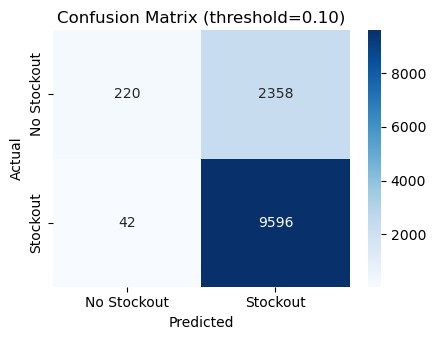

In [35]:
# Confusion matrix using the best threshold from above
from sklearn.metrics import confusion_matrix

chosen_threshold = best["threshold"]
chosen_preds = (probs >= chosen_threshold).astype(int)

cm = confusion_matrix(y_test, chosen_preds)

plt.figure(figsize=(4.5, 3.5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Stockout", "Stockout"],
    yticklabels=["No Stockout", "Stockout"],
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix (threshold={chosen_threshold:.2f})")
plt.tight_layout()
plt.show()

In [37]:
# Export the cleaned combined dataframe used for modeling
# This keeps Item name, Type, Transaction Date, and Sales value
modeling_output_path = "Data/modeling_dataset.csv"
export_cols = [
    "Item name",
    "Transaction Date",
    "Opening Stock",
    "QTY transacted",
    "Closing Stock",
    "Sales value",
    "Type",
]

model_df[export_cols].to_csv(modeling_output_path, index=False)
print(f"Saved modeling dataset to {modeling_output_path}")

Saved modeling dataset to Data/modeling_dataset.csv
